Loading Jackknife samples for Amplitude Ratios...


/var/folders/03/n3scp1nx27g50f8g9_zxcqjh0000gn/T/ipykernel_87833/749403927.py:131: RuntimeWarning: invalid value encountered in divide
  ratio_samples = s1 / s0
/var/folders/03/n3scp1nx27g50f8g9_zxcqjh0000gn/T/ipykernel_87833/749403927.py:139: RuntimeWarning: invalid value encountered in divide
  ratio_samples = s2 / s0
/opt/homebrew/anaconda3/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/opt/homebrew/anaconda3/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


Saved: Factorization_RatioTest_FixedPb_PL-4.pdf


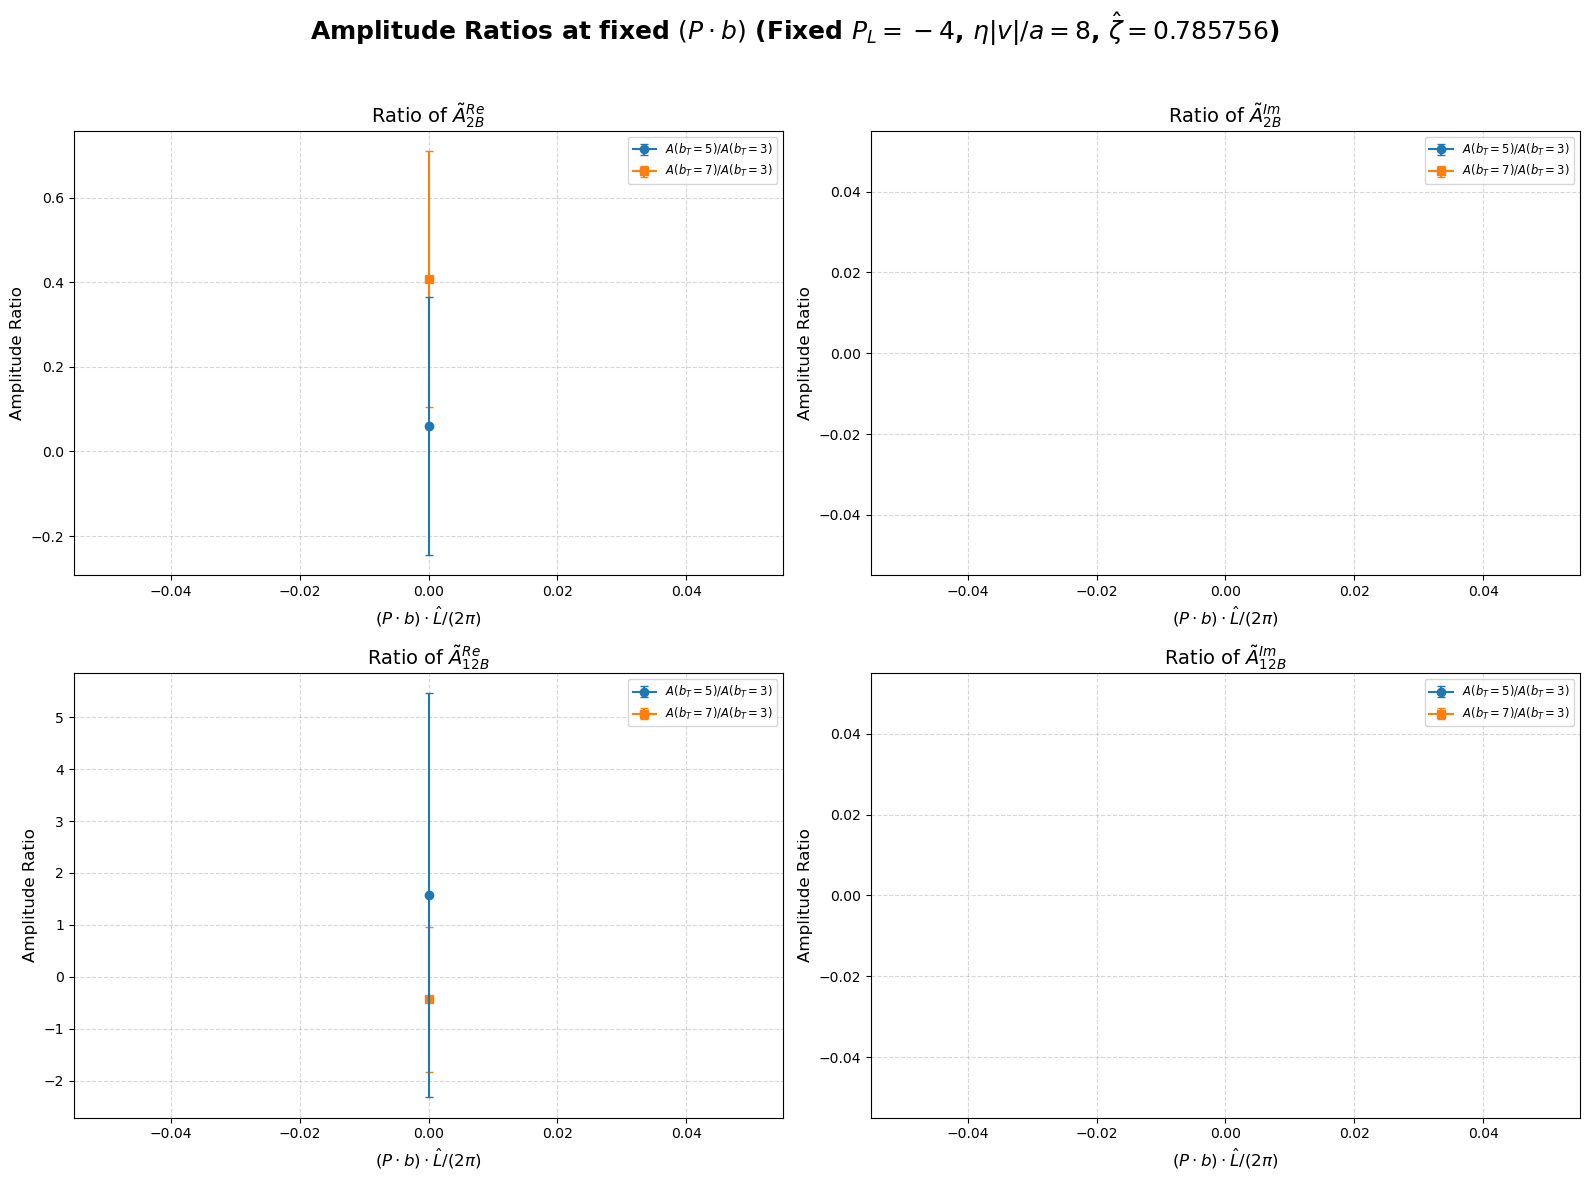

In [1]:
#!/usr/bin/env python
# coding: utf-8

import h5py
import numpy as np
import matplotlib.pyplot as plt
import itertools
import os

# --- 1. Vectorized Jackknife Function ---
def jackknife_vectorized(samples):
    N = samples.shape[1]
    theta_bar = np.mean(samples, axis=1)
    squared_diffs = np.square(samples - theta_bar[:, None])
    sigma_sq = ((N - 1) / N) * np.sum(squared_diffs, axis=1)
    error = np.sqrt(sigma_sq)
    return theta_bar, error

pl_to_zeta = {
    -4: 0.785756,
    -3: 0.539684,
    -2: 0.294367,
    -1: 0.090772
}

# --- 2. Data Loading Helper ---
def get_processed_amplitude_data(filepath, PL):
    try:
        with h5py.File(filepath, "r") as f:
            raw_data = f["Dataset1"][:]
    except FileNotFoundError:
        print(f"File not found: {filepath}")
        return None

    kin = raw_data[:, 0:3]
    samples = raw_data[:, 3:]

    eta, bL, bT = kin[:, 0], kin[:, 1], kin[:, 2]

    # Filter for base eta value from 1 to 10
    mask_eta = (eta >= 0) & (eta <= 10)
    eta_f, bL_f, bT_f = eta[mask_eta], bL[mask_eta], bT[mask_eta]

    # Calculate new variables
    P_dot_b = np.round(bL_f * float(PL), 5)
    b_sq = np.round(bL_f**2 + bT_f**2, 5)

    return {
        'eta': eta_f, 
        'bL': bL_f,
        'bT': bT_f,
        'P_dot_b': P_dot_b, 
        'b_sq': b_sq,
        'samples': samples[mask_eta]
    }

# --- 3. STRICTLY Distinct Color Generator ---
def get_distinct_colors(num_colors):
    distinct_hex = [
        '#e6194b', '#3cb44b', '#4363d8', '#f58231',
        '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe',
        '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000',
        '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080',
        '#000000', '#333333'
    ]
    return [distinct_hex[i % len(distinct_hex)] for i in range(num_colors)]

# --- 4. Ratio Computation and Plotting ---
def plot_ratios_at_fixed_Pb(all_data_dict, PL):
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(fr'Amplitude Ratios at fixed $(P \cdot b)$ (Fixed $P_L={PL}$, $\eta|v|/a = 8$, $\hat{{\zeta}}={pl_to_zeta[int(PL)]}$)', fontsize=18, fontweight='bold')

    axes_flat = axes.flatten()
    
    # We will pick 3 bT values that are most common to form our b1, b2, b3
    # Let's say bT = 3, 5, 7 which are common physical choices.
    bT_refs = [3.0, 5.0, 7.0]
    
    for idx, (amp_name, data) in enumerate(all_data_dict.items()):
        ax = axes_flat[idx]
        
        if amp_name == "ReA2B":
            amp_print = "$\\tilde{{A}}_{{2B}}^{{Re}}$"
        elif amp_name == "ImA2B":
            amp_print = "$\\tilde{{A}}_{{2B}}^{{Im}}$"
        elif amp_name == "ReA12B":
            amp_print = "$\\tilde{{A}}_{{12B}}^{{Re}}$"
        elif amp_name == "ImA12B":
            amp_print = "$\\tilde{{A}}_{{12B}}^{{Im}}$"

        if data is None: 
            ax.text(0.5, 0.5, "No data", ha='center', va='center')
            continue

        # Filter for eta = 8
        mask_eta = np.isclose(data['eta'], 8.0)
        P_dot_b_f = data['P_dot_b'][mask_eta]
        bL_f = data['bL'][mask_eta]
        bT_f = data['bT'][mask_eta]
        samples_f = data['samples'][mask_eta]
        
        unique_P_dot_b = np.unique(P_dot_b_f)
        
        # We will compute R13 = A(bT=3)/A(bT=7) and R23 = A(bT=5)/A(bT=7)
        # Note: Since P_L is fixed, fixing P_dot_b means fixing bL. 
        # So b^2 = bL^2 + bT^2. We vary bT to get different b^2 at the same P_dot_b.
        
        ratio_13_means = []
        ratio_13_errs = []
        ratio_23_means = []
        ratio_23_errs = []
        valid_P_dot_b_13 = []
        valid_P_dot_b_23 = []
        
        for Pb in unique_P_dot_b:
            mask_Pb = (P_dot_b_f == Pb)
            bTs_available = bT_f[mask_Pb]
            samples_Pb = samples_f[mask_Pb]
            
            # Helper to get samples for a specific bT
            def get_s(target_bT):
                idx = np.where(bTs_available == target_bT)[0]
                if len(idx) > 0:
                    return samples_Pb[idx[0]]
                return None
            
            s0 = get_s(bT_refs[0]) # bT=3
            if s0 is not None:
                s1 = get_s(bT_refs[1]) # bT=5
                if s1 is not None:
                    ratio_samples = s1 / s0
                    mean, err = jackknife_vectorized(ratio_samples.reshape(1, -1))
                    ratio_13_means.append(mean[0])
                    ratio_13_errs.append(err[0])
                    valid_P_dot_b_13.append(Pb)
                
                s2 = get_s(bT_refs[2]) # bT=7
                if s2 is not None:
                    ratio_samples = s2 / s0
                    mean, err = jackknife_vectorized(ratio_samples.reshape(1, -1))
                    ratio_23_means.append(mean[0])
                    ratio_23_errs.append(err[0])
                    valid_P_dot_b_23.append(Pb)

        # Plotting
        if len(valid_P_dot_b_13) > 0:
            ax.errorbar(valid_P_dot_b_13, ratio_13_means, yerr=ratio_13_errs, fmt='o-', 
                        label=fr'$A(b_T={bT_refs[1]:.0f}) / A(b_T={bT_refs[0]:.0f})$', capsize=3, zorder=5)
        if len(valid_P_dot_b_23) > 0:
            ax.errorbar(valid_P_dot_b_23, ratio_23_means, yerr=ratio_23_errs, fmt='s-', 
                        label=fr'$A(b_T={bT_refs[2]:.0f}) / A(b_T={bT_refs[0]:.0f})$', capsize=3, zorder=4)

        ax.set_title(fr'Ratio of {amp_print}', fontsize=14)
        ax.set_xlabel(r'$(P \cdot b) \cdot \hat{L} / (2\pi)$', fontsize=12)
        ax.set_ylabel('Amplitude Ratio', fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(fontsize='small', loc='best')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    return fig

# ==========================================
# Main Execution Block
# ==========================================
if __name__ == "__main__":
    PL_value = "-4" 
    path_base = "/Users/hariprashadravikumar/Lattice_QCD_TMD_PhD/sivers_TMD_PhD_project/save_h5_A12B_A2B/TMD_fit/h5data"

    amplitude_files = {
        "ReA2B":  f"{path_base}/ReA2B_PL{PL_value}_jackknife_data.h5",
        "ImA2B":  f"{path_base}/ImA2B_PL{PL_value}_jackknife_data.h5",
        "ReA12B": f"{path_base}/ReA12B_PL{PL_value}_jackknife_data.h5",
        "ImA12B": f"{path_base}/ImA12B_PL{PL_value}_jackknife_data.h5"
    }

    processed_data_store = {}

    print("Loading Jackknife samples for Amplitude Ratios...")
    for amp_name, file_path in amplitude_files.items():
        amplitude_data = get_processed_amplitude_data(file_path, PL_value)
        if amplitude_data is not None:
            processed_data_store[amp_name] = amplitude_data

    if processed_data_store:
        fig_ratios = plot_ratios_at_fixed_Pb(processed_data_store, PL_value)

        # --- SAVE PLOT HERE ---
        save_name = f"Factorization_RatioTest_FixedPb_PL{PL_value}.pdf"
        plt.savefig(save_name, format='pdf', dpi=300, bbox_inches='tight')
        print(f"Saved: {save_name}")

        # plt.show()
